In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")



In [3]:
tickers = [
    "SPY",  # equities
    "TLT",  # long bonds
    "IEF",  # intermediate bonds
    "GLD"   # gold
]

prices = yf.download(
    tickers,
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)["Close"].dropna()

returns = prices.pct_change().dropna()

prices.head()


Ticker,GLD,IEF,SPY,TLT
Date,,,,
2015-01-02,114.080002,83.933151,170.589569,94.760429
2015-01-05,115.800003,84.445305,167.508850,96.249016
2015-01-06,117.120003,85.012566,165.931061,97.983147
2015-01-07,116.430000,84.996811,167.998749,97.789658
2015-01-08,115.940002,84.650108,170.979904,96.494545


In [4]:
vol = returns.rolling(63).std() * np.sqrt(252)
vol = vol.dropna()

vol.tail()


Ticker,GLD,IEF,SPY,TLT
Date,,,,
2026-01-27,0.207330,0.037490,0.116942,0.082573
2026-01-28,0.208845,0.037519,0.114668,0.082277
2026-01-29,0.207469,0.037533,0.114657,0.082042
2026-01-30,0.298781,0.035268,0.114835,0.080393
2026-02-02,0.309273,0.036665,0.112944,0.080635


In [5]:
inv_vol = 1 / vol
weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)

weights.head()


Ticker,GLD,IEF,SPY,TLT
Date,,,,
2015-04-06,0.189617,0.404375,0.224151,0.181857
2015-04-07,0.189040,0.401796,0.228369,0.180795
2015-04-08,0.187898,0.402007,0.227637,0.182459
2015-04-09,0.187997,0.400082,0.231386,0.180535
2015-04-10,0.184267,0.398184,0.236699,0.180849


In [6]:
rp_returns_daily = (weights * returns.loc[weights.index]).sum(axis=1)
rp_returns_daily.head()


Date
2015-04-06    0.003335
2015-04-07    0.000305
2015-04-08   -0.000581
2015-04-09   -0.004241
2015-04-10    0.003536
dtype: float64

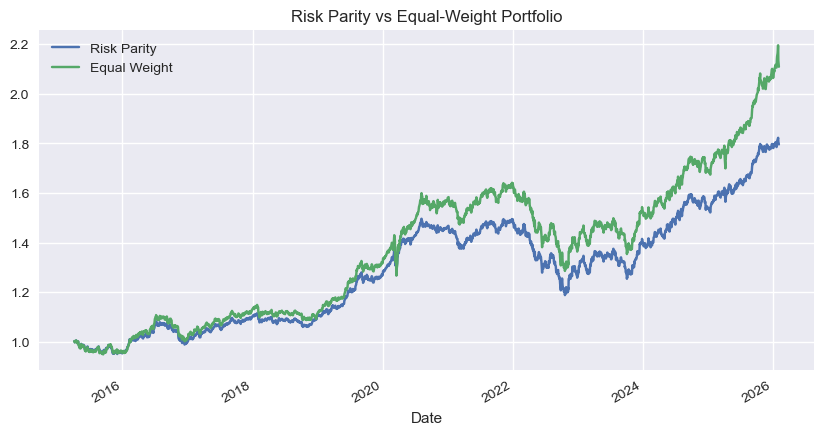

In [7]:
benchmark_returns = returns.loc[weights.index].mean(axis=1)
equity = (1 + pd.DataFrame({
    "Risk Parity": rp_returns_daily,
    "Equal Weight": benchmark_returns
})).cumprod()

equity.plot(
    figsize=(10,5),
    title="Risk Parity vs Equal-Weight Portfolio"
)
plt.show()


In [9]:
# Pick the last date where we have weights
last_date = weights.index[-1]

# Estimate covariance from last 63 trading days
window_returns = returns.loc[:last_date].tail(63)

cov_last = window_returns.cov().values   # 4x4 covariance matrix
w = weights.loc[last_date].values        # weight vector

# Portfolio volatility
port_vol = np.sqrt(w @ cov_last @ w)

# Marginal contribution to risk
mcr = (cov_last @ w) / port_vol

# Total contribution to risk
rc = w * mcr

risk_contrib = pd.Series(rc, index=weights.columns)
risk_contrib_pct = risk_contrib / risk_contrib.sum()

risk_contrib_pct.sort_values(ascending=False)



Ticker
TLT    0.312489
IEF    0.287750
SPY    0.225547
GLD    0.174214
dtype: float64